# **Benchmarking Tabular Models on Banking & Finance**

This notebook explores several datasets from the banking and credit domain to benchmark the performance of popular gradient boosting models (XGBoost, CatBoost) and the transformer-based TabPFN model. The goal is to evaluate their effectiveness on common classification tasks like credit default prediction and loan approval

## Installation [Running this cell required!] <a name="installation"></a>

First, we need to install the necessary libraries. This includes TabPFN itself, as well as other libraries for data manipulation and baseline model comparisons. If you are asked to restart the runtime after installation, please do so.

In [ ]:
## Base library Installation
# Install ucimlrepo for data imports
!pip install ucimlrepo

# Install Baselines for model comparison
!pip install catboost xgboost

# Install the datasets library for loading example data
!pip install datasets

# Install rich for better and more readable printing
!pip install rich


## TabPFN Installation optimized for Google Colab
# Install the TabPFN Client library
!pip install tabpfn-client

# Install tabpfn from source
# Clone the repository: shallow for speedup
!git clone --depth 1 https://github.com/PriorLabs/tabpfn

# Speeding up installation in this notebook:
# Remove torch dependency as it is already installed on colab (do not run this in your local setup)
!sed -i "/torch/d" tabpfn/pyproject.toml

# Step 3: Install using the correct directory name 'tabpfn'
!pip install -e "tabpfn"

# Install TabPFN extensions for additional functionalities
!git clone https://github.com/PriorLabs/tabpfn-extensions

# Speeding up installation in this notebook:
# Remove torch dependency as it is already installed on colab (do not run this in your local setup)
!sed -i "/torch/d" tabpfn-extensions/pyproject.toml

!pip install -e tabpfn-extensions[all]

### ***Note: remember to restart the runtime after the installation.***

## Necessary Imports for the Notebook [Running this cell required!]

Now that the libraries are installed, let's import all the necessary modules for this notebook.

In [1]:
# Standard Library Imports
from ucimlrepo import fetch_ucirepo

# TabPFN and Extensions
try:
    from tabpfn import TabPFNClassifier, TabPFNRegressor
    from tabpfn_extensions import interpretability
    from tabpfn_extensions.post_hoc_ensembles.sklearn_interface import (
        AutoTabPFNClassifier,
    )
except ImportError:
    raise ImportError(
        "Warning: Could not import TabPFN / TabPFN extensions. Please run installation above and restart the session afterwards (Runtime > Restart Session)."
    )

# Data Science & Visualization
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

# Other ML Models
from catboost import CatBoostClassifier, CatBoostRegressor

# Notebook UI/Display
from IPython.display import Markdown, display
from rich.console import Console
from rich.panel import Panel
from rich.prompt import Prompt
from rich.rule import Rule
from sklearn.compose import make_column_selector, make_column_transformer


# Scikit-Learn: Models
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_squared_error, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from xgboost import XGBClassifier, XGBRegressor

# This transformer will be used to handle categorical features for the baseline models
column_transformer = make_column_transformer(
    (
        OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
        make_column_selector(dtype_include=["object", "category"]),
    ),
    remainder="passthrough",
)

/home/guptaa/anshul/simplified-insurance-dataset-benchmarking/tablab/lib/python3.10/site-packages/hyperopt/atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## <b>Classification with TabPFN <a name="classification"></a></b>

We will compare TabPFN's performance against other popular machine learning models: RandomForest, XGBoost, and CatBoost. The performance metric we will use is the [ROC AUC](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html) score.


In [2]:
# 1. German Credit Dataset (To classify good or bad credit risks)
# Source: https://archive.ics.uci.edu/dataset/144/
# Rows: 1000
# Features: 21
# Target: class
dataset = "german_credit"
statlog_german_credit_data = fetch_ucirepo(id=144)
X = statlog_german_credit_data.data.features
# since https://www.kaggle.com/datasets/uciml/german-credit/data mentions only these features are useful
X = X[[
    'Attribute9', #sex
    'Attribute13', #age
    'Attribute17', #job
    'Attribute15', #housing
    'Attribute6', #savings account
    'Attribute1', #checking account
    'Attribute5', #credit amount
    'Attribute2', #duration
    'Attribute4', #purpose
]]
y = statlog_german_credit_data.data.targets
df = pd.concat([X, y], axis=1)

In [3]:
# Alternative datasets (commented for reference):
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 2. Bank Marketing (To predict if the client will subscribe a term deposit).
# Source: https://archive.ics.uci.edu/dataset/222/
# Rows: 45211
# Features: 17
# Target: y
dataset = "bank_marketing"
bank_marketing = fetch_ucirepo(id=222)
X = bank_marketing.data.features
y = bank_marketing.data.targets
df = pd.concat([X, y], axis=1)
print(df.head())
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 3. credit-approval (This data concerns credit card applications).
# Source: https://archive.ics.uci.edu/dataset/27/
# Rows: 690
# Features: 16
# Target: A16
# dataset = "credit_approval"
# credit_approval = fetch_ucirepo(id=27)
# X = credit_approval.data.features
# y = credit_approval.data.targets
# df = pd.concat([X, y], axis=1)
# print(df.head())
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 4. australian-credit (This data concerns australian credit card applications).
# Source: https://archive.ics.uci.edu/dataset/143/
# Rows: 690
# Features: 15
# Target: A15
# dataset = "australian_credit"
# australian_credit = fetch_ucirepo(id=143)
# X = australian_credit.data.features
# y = australian_credit.data.targets
# df = pd.concat([X, y], axis=1)
# print(df.head())
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 5. default-credit-card (To predict default payment of customers in Taiwan).
# Source: https://archive.ics.uci.edu/dataset/350/
# Rows: 30000
# Features: 24
# Target: Y
# dataset = "default_credit_card"
# default_credit_card = fetch_ucirepo(id=350)
# X = default_credit_card.data.features
# y = default_credit_card.data.targets
# df = pd.concat([X, y], axis=1)
# print(df.head())
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 6. loan-modelling (To check if user accepts the personal loan offered in the last campaign?)
# Source: https://www.kaggle.com/datasets/teertha/personal-loan-modeling
# Rows: 5000
# Features: 14
# Target: Personal Loan
# dataset = "loan_modelling"
# !wget -q -O loan_modelling.csv https://media.githubusercontent.com/media/anshulg954/tabbank/refs/heads/main/datasets/Bank_Personal_Loan_Modelling.csv
# df = pd.read_csv("loan_modelling.csv")
# X = df.drop(columns=["Personal Loan"])
# y = df["Personal Loan"]
# print(df.head())
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 7. credit-risk (To predict the loan status from simulating credit bureau data)
# Source: https://www.kaggle.com/datasets/laotse/credit-risk-dataset/
# Rows: 32581
# Features: 12
# Target: loan_status
# dataset = "credit_risk"
# !wget -q -O credit_risk.csv https://media.githubusercontent.com/media/anshulg954/tabbank/refs/heads/main/datasets/credit_risk_dataset.csv
# df = pd.read_csv("credit_risk.csv")
# X = df.drop(columns=["loan_status"])
# y = df["loan_status"]
# print(df.head())
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 8. hmeq (To predict whether an applicant eventually defaulted or was seriously delinquent in home equity data)
# Source: https://www.kaggle.com/datasets/ajay1735/hmeq-data/
# Rows: 5960
# Features: 13
# Target: BAD
# dataset = "hmeq"
# !wget -q -O hmeq.csv https://media.githubusercontent.com/media/anshulg954/tabbank/refs/heads/main/datasets/hmeq.csv
# df = pd.read_csv("hmeq.csv")
# X = df.drop(columns=["BAD"])
# y = df["BAD"]
# print(df.head())
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 9. loan-approval (To predict the likelihood of loan approval based on features like  cibil score, income, employment status, loan term, loan amount, assets value)
# Source: https://www.kaggle.com/datasets/architsharma01/loan-approval-prediction-dataset
# Rows: 4269
# Features: 13
# Target: loan_status
# dataset = "loan_approval"
# !wget -q -O loan_approval.csv https://media.githubusercontent.com/media/anshulg954/tabbank/refs/heads/main/datasets/loan_approval_dataset.csv
# df = pd.read_csv("loan_approval.csv")
# X = df.drop(columns=["loan_status"])
# y = df["loan_status"]
# print(df.head())
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# 10. loan-repay (To predict predict whether or not the borrower paid back their loan in full)
# Source: https://www.kaggle.com/datasets/architsharma01/loan-approval-prediction-dataset
# Rows: 9578
# Features: 14
# Target: not.fully.paid
# dataset = "loan_repay"
# !wget -q -O loan_repay.csv https://media.githubusercontent.com/media/anshulg954/tabbank/refs/heads/main/datasets/loan_data.csv
# df = pd.read_csv("loan_repay.csv")
# X = df.drop(columns=["not.fully.paid"])
# y = df["not.fully.paid"]
# print(df.head())


In [4]:
# Subsampling for datasets with samples > 10k
target_col = y.columns[0] if isinstance(y, pd.DataFrame) else y.name

# Sample 10k data points using stratified sampling
n_samples = 10000
if len(df) > n_samples:
    # --- Check nunique() on the column in the merged frame ---
    if df[target_col].nunique() > 1:
        # Perform stratified sampling based on the target column
        df_sampled = df.groupby(target_col, group_keys=False).apply(
            lambda x: x.sample(n=min(len(x), int(n_samples * len(x) / len(df))), random_state=42)
        )
    else:
        # Fallback to simple random sampling if stratification is not possible
        print("Stratified sampling not possible. Using simple random sampling.")
        df_sampled = df.sample(n=n_samples, random_state=42)
    print(f"Original dataset size: {len(df_merged)}")
    print(f"Sampled dataset size: {len(df_sampled)}")
else:
    df_sampled = df.copy()
    print(f"Dataset size is less than {n_samples}, using the entire dataset.")

X = df_sampled.drop(columns=[target_col])
y = df_sampled[[target_col]]

Dataset size is less than 10000, using the entire dataset.


In [5]:
# Compare different machine learning models by training each one multiple times
# on different parts of the data and averaging their performance scores for a
# more reliable performance estimate

# Encode target labels to classes for baselines
le = LabelEncoder()
y = le.fit_transform(y)

# Define models
models = [
    (
        "TabPFN",
        make_pipeline(
            column_transformer,
            TabPFNClassifier(random_state=42),
        ),
    ),
    (
        "AutoTabPFN",
        make_pipeline(
            column_transformer,
            AutoTabPFNClassifier(random_state=42, max_time=1800),
        ),
    ),
    (
        "RandomForest",
        make_pipeline(
            column_transformer,  # string data needs to be encoded for model
            RandomForestClassifier(random_state=42),
        ),
    ),
    (
        "XGBoost",
        make_pipeline(
            column_transformer,  # string data needs to be encoded for model
            XGBClassifier(random_state=42),
        ),
    ),
    (
        "CatBoost",
        make_pipeline(
            column_transformer,  # string data needs to be encoded for model
            CatBoostClassifier(random_state=42, verbose=0),
        ),
    ),
]

# Calculate scores
n_splits = 3
cv = StratifiedKFold(n_splits=n_splits, random_state=42, shuffle=True)
scoring = "roc_auc_ovr" if len(np.unique(y)) > 2 else "roc_auc"
scores = {
    name: cross_val_score(
        model, X, y, cv=cv, scoring=scoring, n_jobs=1, verbose=1
    )
    for name, model in models
}

df_scores = pd.DataFrame([(k, v.mean(), v.std()) for (k, v) in scores.items()], columns=["Model", "ROC AUC Mean", "ROC AUC STD"])
# ax = df_scores.plot(x="Model", y="ROC AUC", kind="bar", figsize=(10, 6))
# ax.set_ylim(df_scores["ROC AUC"].min() * 0.995, min(1.0, df_scores["ROC AUC"].max() * 1.005))
# ax.set_title(f"Model Comparison - {n_splits}-fold Cross-validation")

# # Add ROC AUC values above bars
# for i, v in enumerate(df_scores["ROC AUC"]):
#     ax.text(i, v + 0.001, f"{v:.4f}", ha="center", va="bottom", fontsize=10)

# plt.tight_layout()
# plt.show()

/home/guptaa/anshul/simplified-insurance-dataset-benchmarking/tablab/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:   15.3s finished


tabpfn-v2-classifier-vutqq28w.ckpt:   0%|          | 0.00/12.9M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

tabpfn-v2-classifier-od3j1g5m.ckpt:   0%|          | 0.00/29.0M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

...

tabpfn-v2-classifier.ckpt:   0%|          | 0.00/29.0M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

tabpfn-v2-classifier-znskzxi4.ckpt:   0%|          | 0.00/12.9M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:  7.4min finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    1.1s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.5s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    5.6s finished


In [6]:
# Convert the scores dictionary to a DataFrame
df_scores_folds = pd.DataFrame(scores)
df_scores_folds.rename(columns={'index': 'Fold'}, inplace=True)
display(df_scores_folds)
df_scores_folds.to_csv(f'rawscores_{dataset}.csv', index=False)
print("\nScores saved to results.csv")

,TabPFN,AutoTabPFN,RandomForest,XGBoost,CatBoost
0,0.787115,0.779530,0.765000,0.719274,0.767692
1,0.759249,0.748369,0.742339,0.723863,0.767382
2,0.800000,0.789356,0.760558,0.740300,0.773648



Scores saved to results.csv


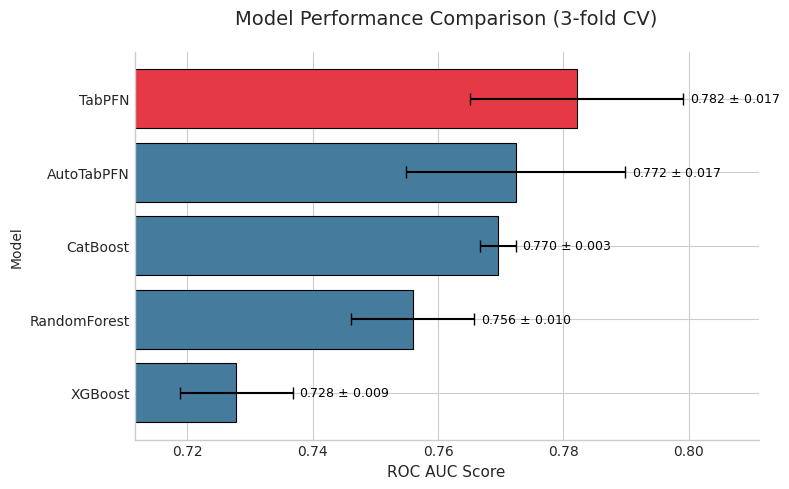

In [7]:
plt.style.use('seaborn-v0_8-whitegrid') # Use a nice style
fig, ax = plt.subplots(figsize=(8, 5)) # Create figure and axes
df_scores.sort_values(by="ROC AUC Mean", ascending=False, inplace=True) # Sort by ROC AUC Mean
# Create a color list to highlight the best model
max_roc_auc_index = df_scores["ROC AUC Mean"].idxmax()
top_model = df_scores.loc[max_roc_auc_index, "Model"]
colors = ['#e63946' if model == top_model else '#457b9d' for model in df_scores['Model']]


# --- 3. Create the Horizontal Bar Plot ---
ax.barh(
    df_scores["Model"],
    df_scores["ROC AUC Mean"],
    xerr=df_scores["ROC AUC STD"],
    color=colors,
    capsize=4,
    edgecolor='black',
    linewidth=0.8
)

# Invert y-axis to have the best model on top
ax.invert_yaxis()

# --- 4. Refine Labels and Annotations ---
# Add the "Mean ± STD" text at the end of each bar
for i, (mean, std) in enumerate(zip(df_scores["ROC AUC Mean"], df_scores["ROC AUC STD"])):
    ax.text(
        mean + std + 0.001, # Position text just after the error bar
        i,
        f"{mean:.3f} $\\pm$ {std:.3f}",
        ha="left",
        va="center",
        fontsize=9,
        color='black'
    )

# --- 5. Final Touches for a Polished Look ---
ax.set_title('Model Performance Comparison (3-fold CV)', fontsize=14, pad=20)
ax.set_xlabel('ROC AUC Score', fontsize=11)
ax.set_ylabel('Model') # The model names on the y-axis are self-explanatory

# Set a "zoomed-in" x-axis limit to highlight differences
min_score = (df_scores["ROC AUC Mean"] - df_scores["ROC AUC STD"]).min()
max_score = (df_scores["ROC AUC Mean"] + df_scores["ROC AUC STD"]).max()
ax.set_xlim(min_score * 0.99, max_score * 1.015) # e.g. (0.735, 0.79)

# Remove top and right borders for a modern look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'plot_{dataset}.png')
plt.show()

## Feature selection

Feature selection is the process of selecting a subset of relevant features for use in model construction. It's useful for reducing model complexity, improving performance by removing noise, and decreasing training time. Here, we'll use Sequential Forward Selection (SFS), which starts with no features and iteratively adds the feature that most improves the model's performance.

The goal is to see if we can create a simpler, faster model with fewer features without a significant drop in accuracy.

In [8]:
le = LabelEncoder()
y = le.fit_transform(y)

X_enc = column_transformer.fit_transform(X)

feature_names = X.columns
n_features = 6  #Number of features to select

# Initialize model
clf = TabPFNClassifier(n_estimators=1)

# Feature selection
sfs = interpretability.feature_selection.feature_selection(
    estimator=clf, X=X_enc, y=y, n_features_to_select=n_features, feature_names=feature_names
)

# Print selected features
selected_features = [
    feature_names[i] for i in range(len(feature_names)) if sfs.get_support()[i]
]
print("\nSelected features:")
for feature in selected_features:
    print(f"- {feature}")


Selected features:
- Attribute17
- Attribute15
- Attribute6
- Attribute1
- Attribute2
- Attribute4


**Subset of data selected based on feature importance**

In [9]:
X_selected = X[selected_features]
X_selected.head()

,Attribute17,Attribute15,Attribute6,Attribute1,Attribute2,Attribute4
0,A173,A152,A65,A11,6,A43
1,A173,A152,A61,A12,48,A43
2,A172,A152,A61,A14,12,A46
3,A173,A153,A61,A11,42,A42
4,A173,A153,A61,A11,24,A40


In [10]:
X_enc = column_transformer.fit_transform(X_selected)
X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y, test_size=0.20, random_state=42
)

# Train and evaluate the TabPFN classifier
tabpfn_classifier = TabPFNClassifier(random_state=42)
tabpfn_classifier.fit(X_train, y_train)
y_pred_proba = tabpfn_classifier.predict_proba(X_test)

# Calculate the ROC AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
print(f"TabPFN ROC AUC Score: {roc_auc:.4f}")

TabPFN ROC AUC Score: 0.8193


## Summary and Conclusion

This notebook provided an overview of several key banking and credit-related datasets for tabular classification. We demonstrated how to set up a pipeline to benchmark XGBoost, CatBoost, and TabPFN.

**Key Takeaways:**
- **Data Size and Complexity:** Datasets in this domain vary greatly, from the small German Credit dataset to the massive Lending Club dataset. Preprocessing and feature engineering are often critical steps. However, even with minimal preprocessing achieving great results showcases a stronger backbone behind TabPFN.
- **Model Performance:**
    - **XGBoost and CatBoost** are powerful, scalable models that are well-suited for larger datasets. They often achieve state-of-the-art performance but may require some tuning.
    - **TabPFN** is an excellent baseline model for smaller datasets (typically <10k rows, <100 features). It's incredibly fast to train as it requires no hyperparameter tuning, making it great for initial exploration.

For a comprehensive benchmark, one would need to perform careful feature engineering, handle missing data robustly, and conduct hyperparameter tuning for the gradient boosting models.

Contact: For questions or contributions, reach out to me @ anshulg2743@gmail.com.